# Glass drying model

An original toy model inspired by **Glass-Drying Physics Simulation**, credited to Barron Roth in the Awesome GPT-6 Astra catalog.

Sources: [original creator post](https://x.com/iamBarronRoth/status/2096407730030530762) · [Awesome GPT-6 Astra](https://github.com/magiccreator-ai/awesome-gpt-6-astra#glass-drying-physics-simulation)

> This is an illustrative first-order model, not validated fluid dynamics and not a reproduction of the cited simulation.


## Look → predict → run
**Learn:** separate a rate constant from an initial amount, and a model assumption from evidence.
**Predict:** if the evaporation constant doubles, does drying time halve for a two-component mixture?
We compare free and trapped water with different decay rates. The long tail is controlled by the slower component.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astra_utils import style, animate_tracks, COLORS
style()


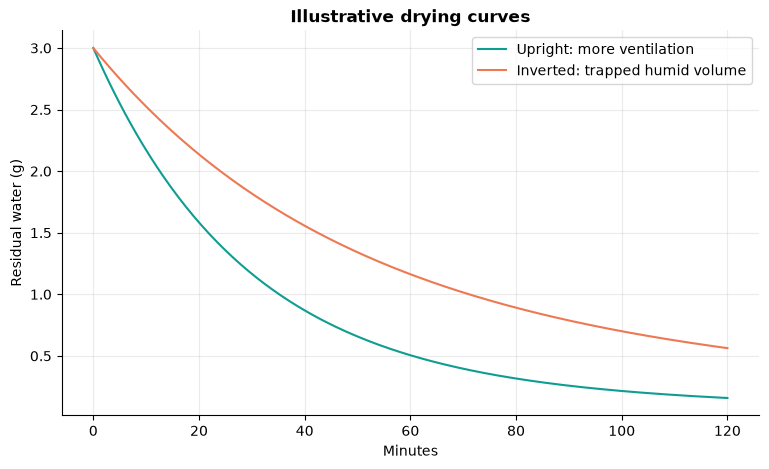

upright time below threshold: >120 min
inverted time below threshold: >120 min


In [2]:
import numpy as np
import matplotlib.pyplot as plt

minutes = np.linspace(0, 120, 241)
m0 = 3.0  # grams of residual water

def water_remaining(k_evap, trapped_fraction=0.0, k_trap=.006):
    free = m0*(1-trapped_fraction)*np.exp(-k_evap*minutes)
    trapped = m0*trapped_fraction*np.exp(-k_trap*minutes)
    return free + trapped

upright = water_remaining(.035, trapped_fraction=.08)
inverted = water_remaining(.022, trapped_fraction=.28)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(minutes, upright, label='Upright: more ventilation')
ax.plot(minutes, inverted, label='Inverted: trapped humid volume')
ax.set(xlabel='Minutes', ylabel='Residual water (g)', title='Illustrative drying curves')
ax.legend(); ax.grid(alpha=.25); plt.show()

threshold=.15
for name, curve in [('upright', upright), ('inverted', inverted)]:
    idx=np.where(curve<threshold)[0]
    print(name, 'time below threshold:', f'{minutes[idx[0]]:.1f} min' if len(idx) else '>120 min')


## Interpretation
The result follows from the chosen rate constants; it is not evidence that one real-world orientation always dries faster. Change humidity assumptions, drainage, contact geometry, or the trapped-water fraction and compare sensitivity.


## Make the assumptions visible
The model is `m(t) = m₀[(1−f) exp(−k t) + f exp(−k_trap t)]`.
The heatmap varies **both** trapped fraction and the free-water rate while holding other assumptions fixed.
A bright cell means more water remains after 60 minutes, not a measured outcome.


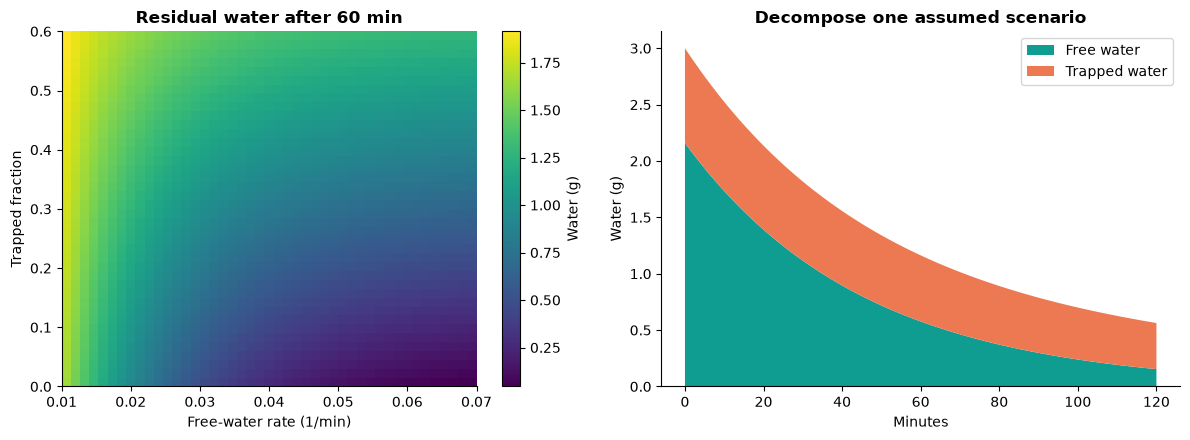

In [3]:
fractions=np.linspace(0,.6,40)
rates=np.linspace(.01,.07,45)
K,F=np.meshgrid(rates,fractions)
remaining=m0*((1-F)*np.exp(-K*60)+F*np.exp(-.006*60))
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
im=axes[0].imshow(remaining,origin='lower',extent=(.01,.07,0,.6),aspect='auto',cmap='viridis')
axes[0].set(xlabel='Free-water rate (1/min)',ylabel='Trapped fraction',title='Residual water after 60 min')
fig.colorbar(im,ax=axes[0],label='Water (g)')
free=m0*(1-.28)*np.exp(-.022*minutes)
trapped=m0*.28*np.exp(-.006*minutes)
axes[1].stackplot(minutes,free,trapped,labels=['Free water','Trapped water'],colors=COLORS[:2])
axes[1].set(xlabel='Minutes',ylabel='Water (g)',title='Decompose one assumed scenario'); axes[1].legend()
fig.tight_layout(); plt.show()
assert np.all(np.diff(inverted)<=0) and np.isclose(inverted[0],m0)


**Experiment:** set trapped fraction to zero. Explain why the single-exponential intuition works better
then. Identify a real measurement that could estimate each rate constant before using this model predictively.
